In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.DataFrame(columns = ["model", "database", "positive_train", "negative_train", "positive_test", "negative_test", "k"])

for file in os.listdir("./results"):
    if file.endswith(".txt"):
        file_name = file.split(".txt")[0]
        parts = file_name.split("_")
        model = parts[0]
        database = parts[1]
        if model != "BerryFinder":
            k = int(parts[2])
        f = open(os.path.join("./results", file), "r")
        lines = f.readlines()
        if len(lines) == 0:
            print("Empty file:", file)
            continue
        if lines[0].startswith("WARNING"):
            lines = lines[1:]
        pos_train = float(lines[1].strip().split(": ")[1])
        neg_train = float(lines[2].strip().split(": ")[1])
        pos_test = float(lines[4].strip().split(": ")[1])
        neg_test = float(lines[5].strip().split(": ")[1])
        if model == "BerryFinder":
            k = int(lines[6].strip().split(":  ")[1])
        df.loc[len(df)] = [model, database, pos_train, neg_train, pos_test, neg_test, k]


In [3]:
# df[(df["database"] == "MIMIC-IV") & (df["model"] == "BSD")][["train", "k"]].sort_values(by="k", ascending=False)

In [4]:
df.to_csv("results.csv")

In [5]:
df["train"] = df["positive_train"] - df["negative_train"]
df["test"] = df["positive_test"] - df["negative_test"]

In [6]:
df_d = df[df["database"] == "Depression"]
a = df_d.groupby("model").max()[["train", "test"]]
# a["train"]- a["test"]

In [7]:
df["model"] = df["model"].replace({"SDMapStar": "SDMap*"})

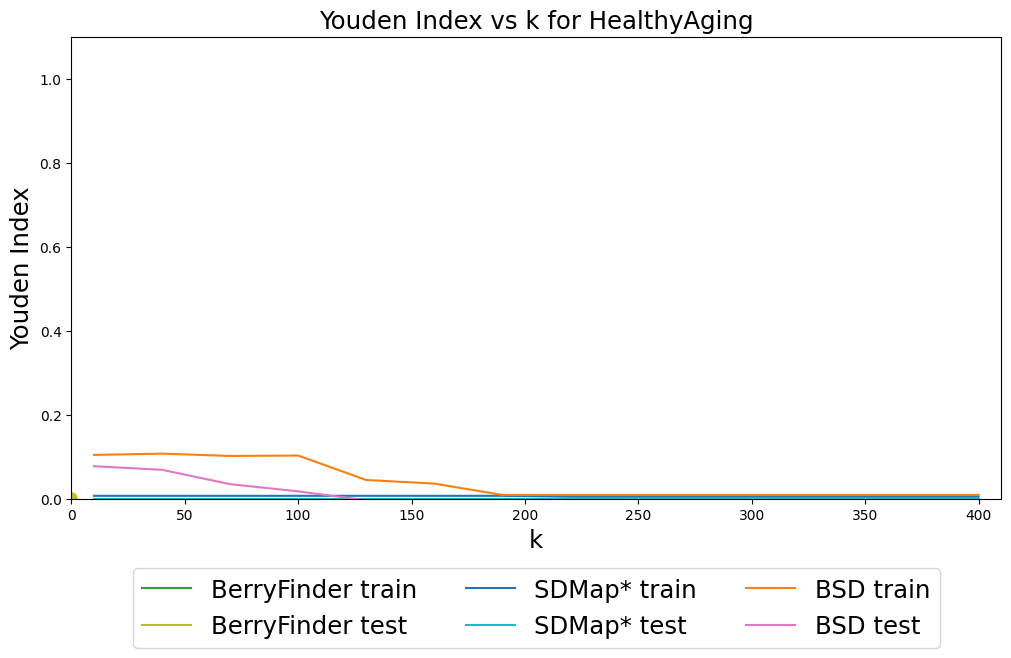

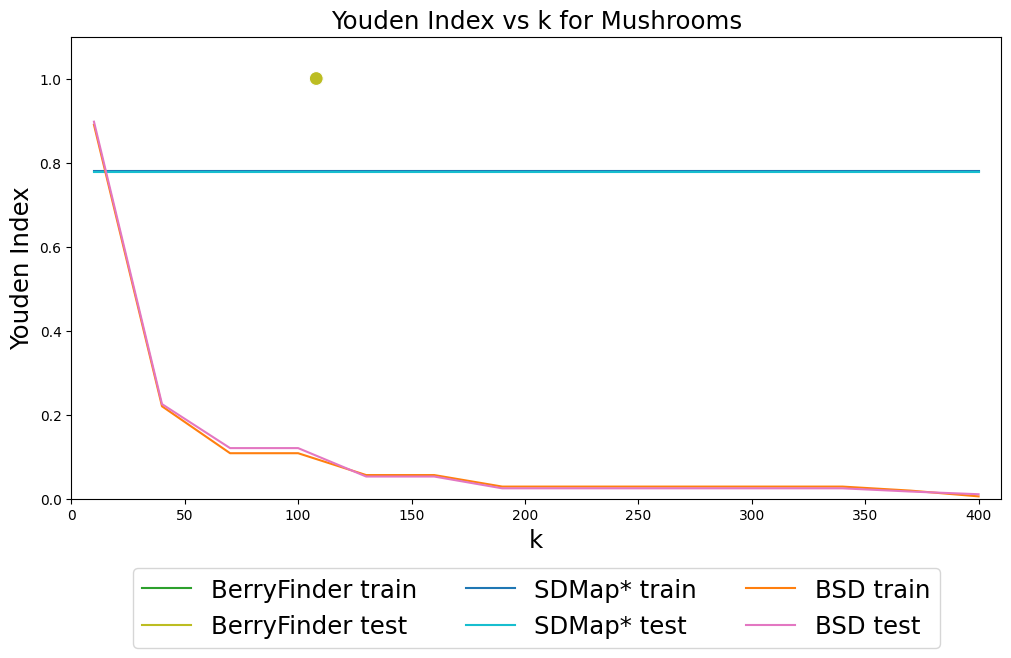

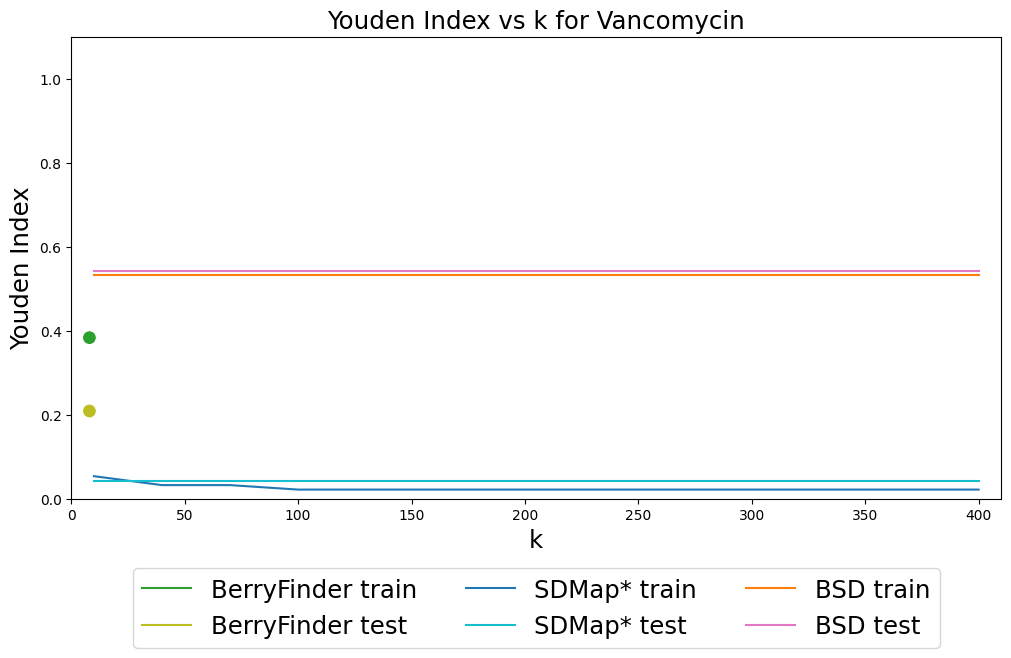

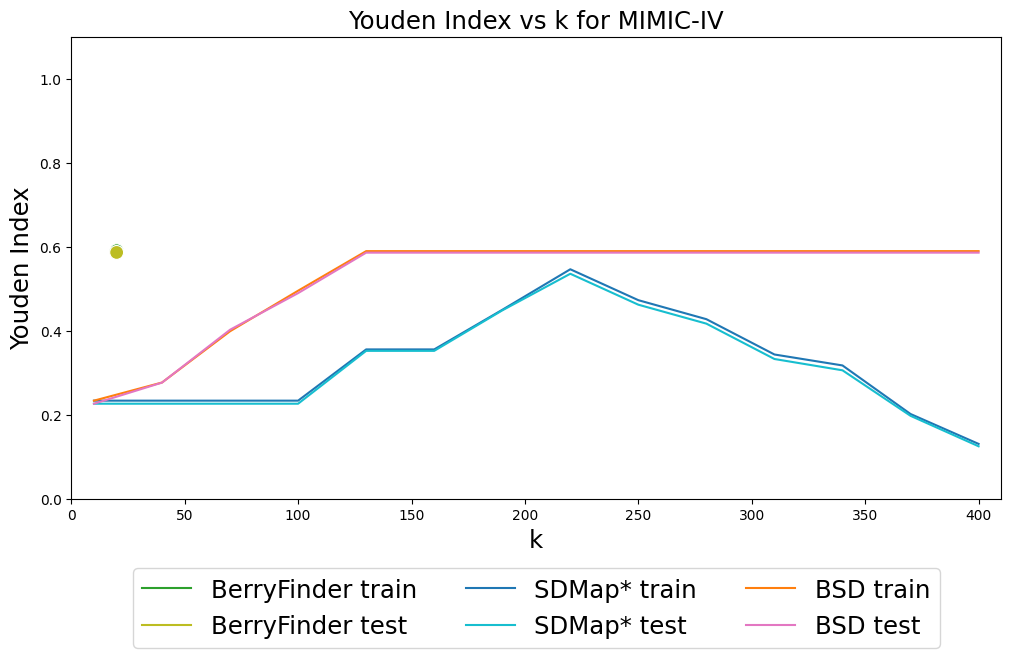

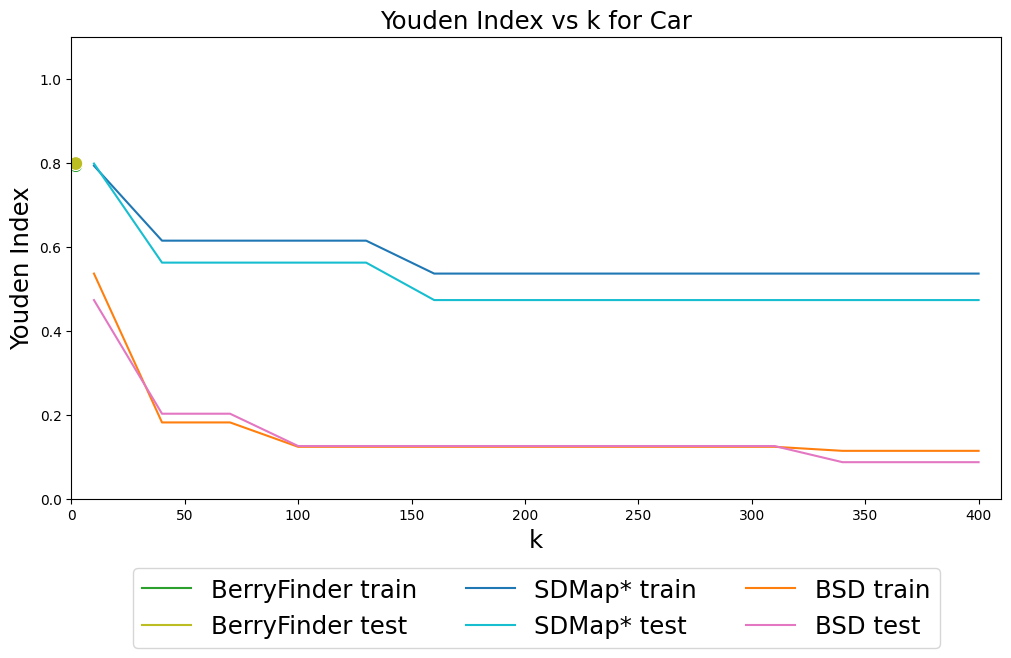

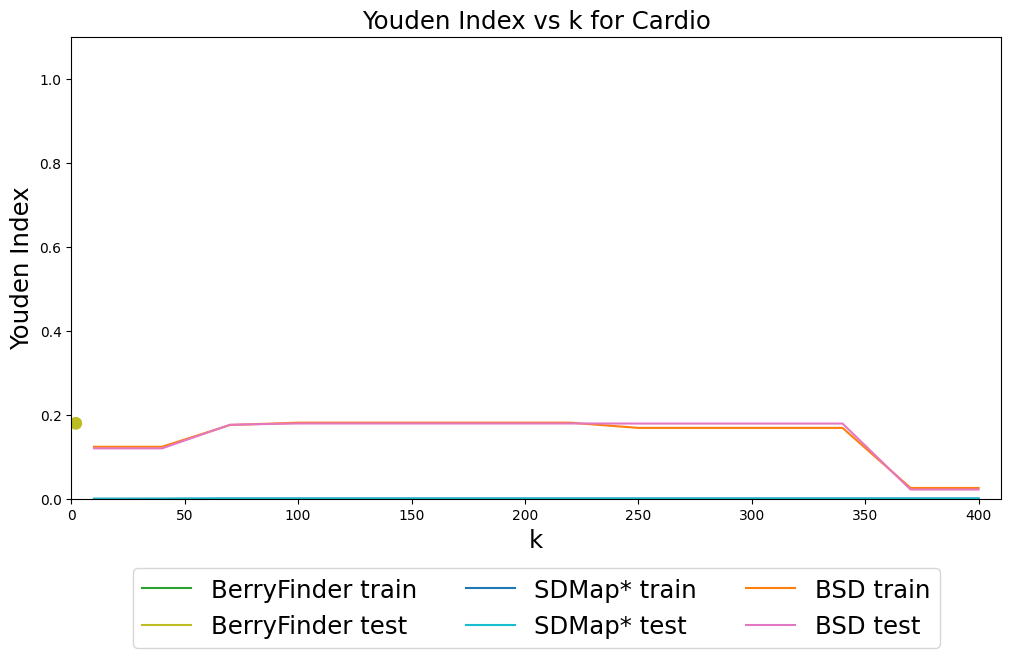

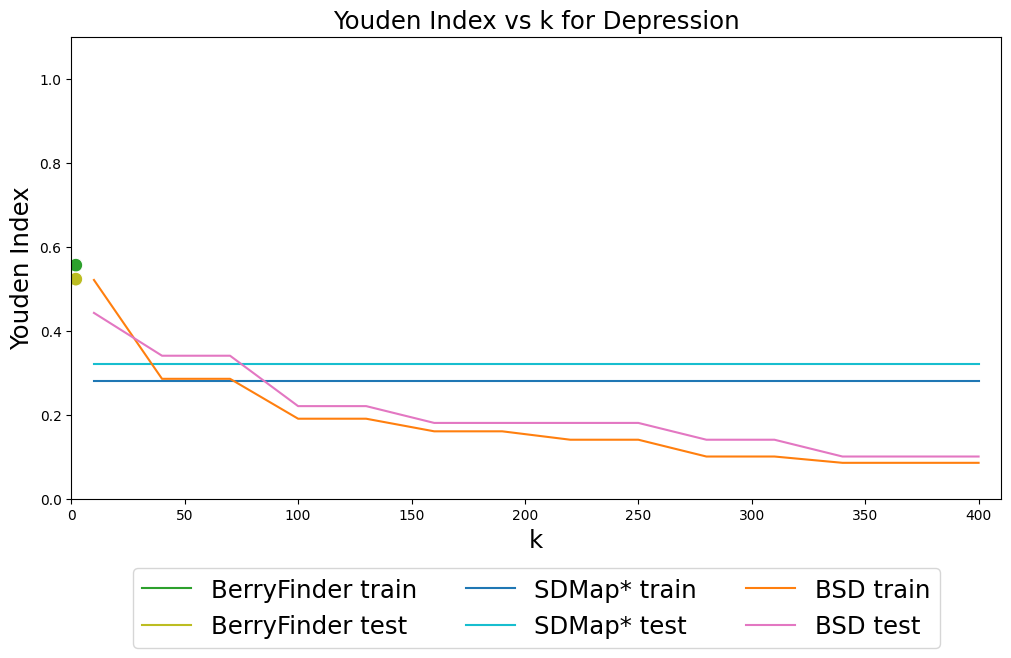

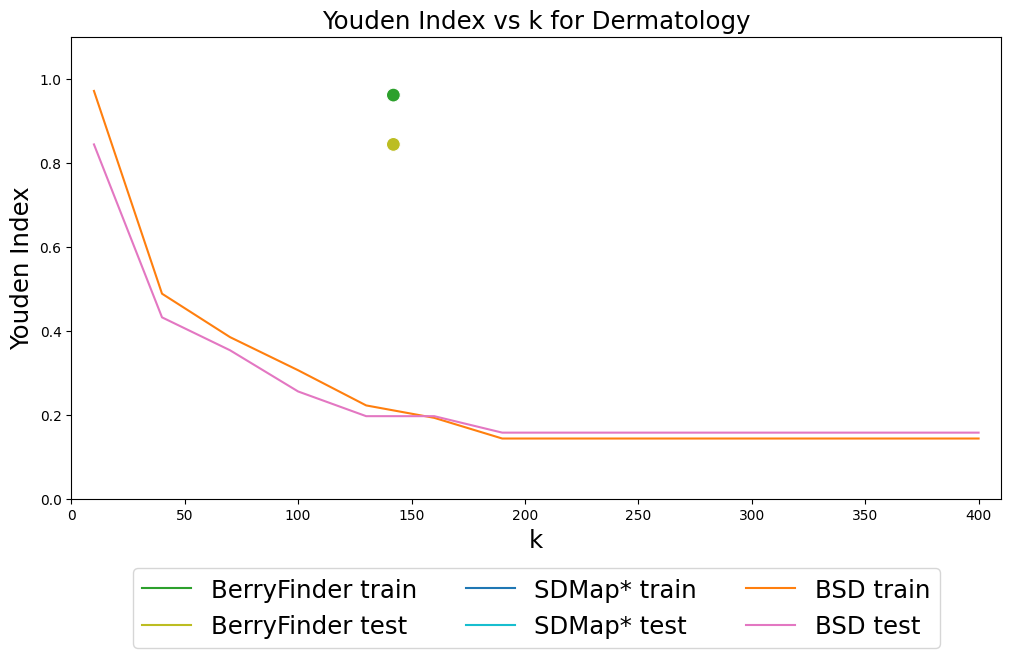

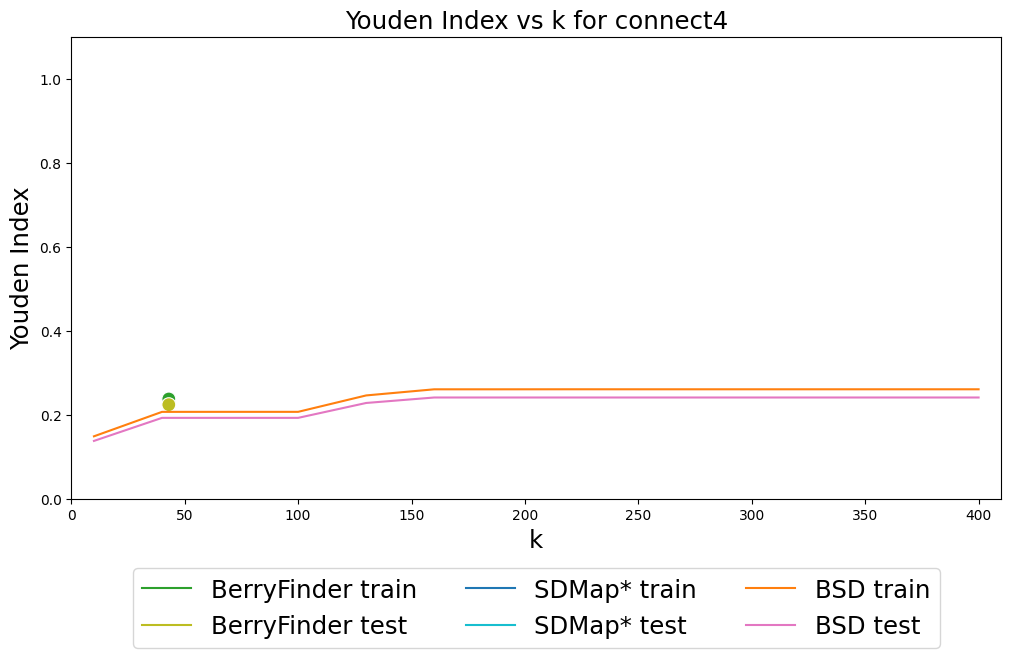

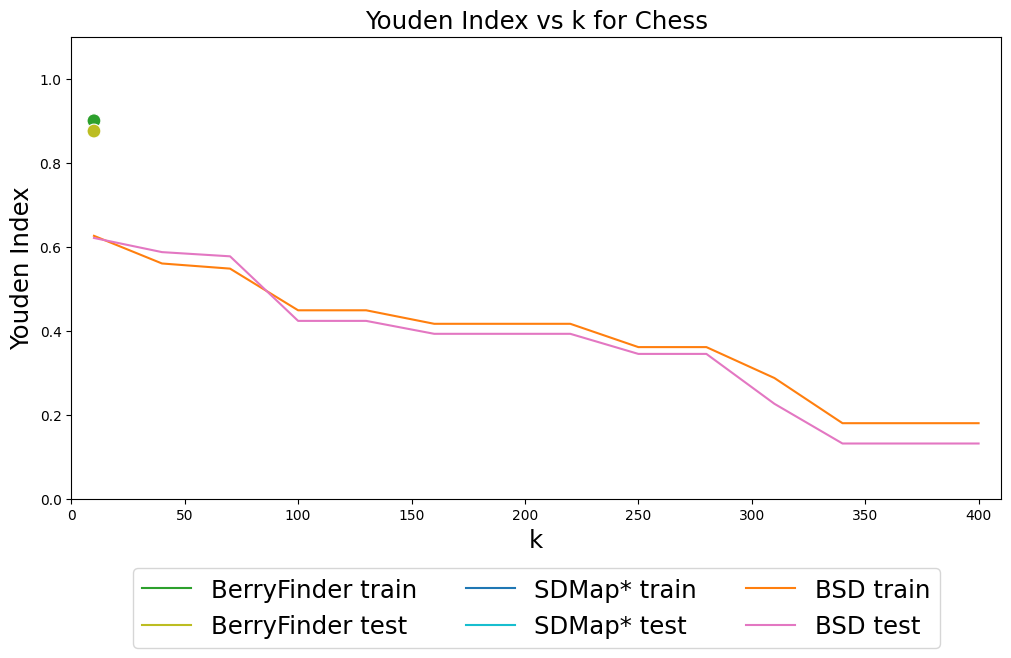

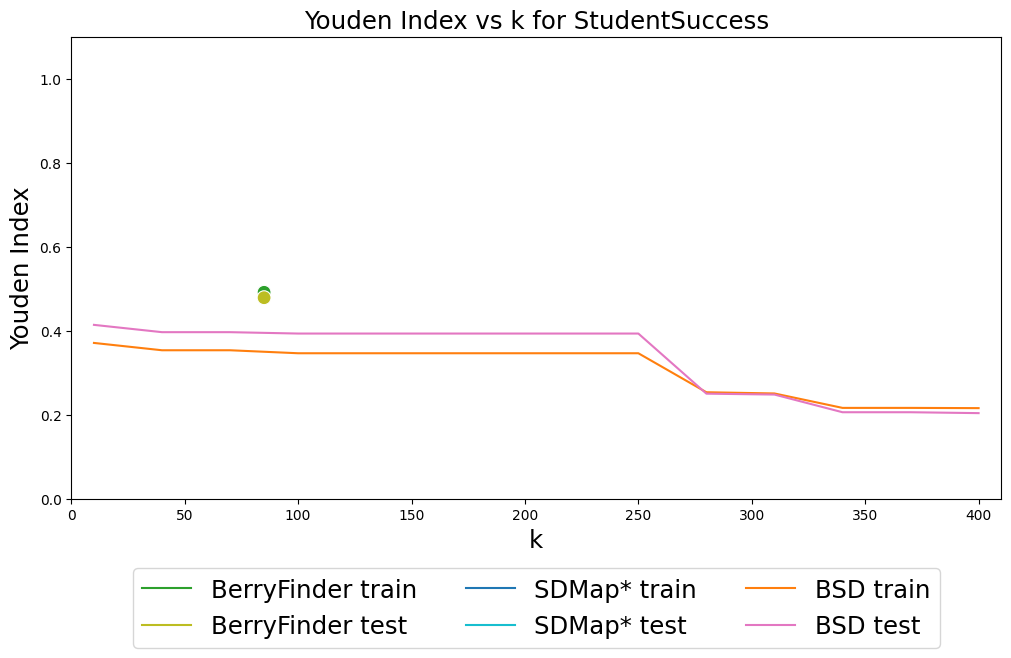

In [8]:
color_map = {
    # "BerryFinder train" : "purple",
    # "BerryFinder test" : "blue",
    # "SDMap* train" : "red",
    # "SDMap* test" : "orange",
    # "BSD train" : "green",
    # "BSD test" : "navy",
    "BerryFinder train": "tab:green",
    "BerryFinder test": "tab:olive",
    "SDMap* train": "tab:blue",
    "SDMap* test": "tab:cyan",
    "BSD train": "tab:orange",
    "BSD test": "tab:pink",
    "Q-Finder train": "tab:red",
    "Q-Finder test": "tab:brown"
}

palette = {
    "Q-Finder train": "tab:red",
    "Q-Finder test": "tab:red",
    "BerryFinder train": "tab:green",
    "BerryFinder test": "tab:green",
    "SDMap* train": "tab:blue",
    "SDMap* test": "tab:blue",
    "BSD train": "tab:orange",
    "BSD test": "tab:orange",
    # "BerryFinderNoPrune": "tab:purple"

}


label_order = [ "BerryFinder train", "BerryFinder test", "SDMap* train", "SDMap* test", "BSD train", "BSD test" ]

datasets_on_experiments_section = ["Mushrooms", "Depression", "MIMIC-IV", "Chess", "HealthyAging"]

for d in df['database'].unique():
    if d == "Soybean":
        continue
    fontsize = 22
    plt.figure(figsize=(12, 6))
    df_d = df[df['database'] == d]
    df_d_melt = df_d.melt(id_vars=['model', 'k'], value_vars=['train', 'test'], var_name='set', value_name='Youden_index')
    df_d_melt["hue"] = df_d_melt["model"] + " " + df_d_melt["set"]
    sns.lineplot(data=df_d_melt, x='k', y='Youden_index', hue='hue', markers=True, dashes=False, palette=color_map, hue_order=label_order)
    sns.scatterplot(data=df_d_melt[df_d_melt["model"] == "BerryFinder"], x='k', y='Youden_index', hue='hue', s=100, legend=False, palette=color_map, hue_order=label_order)
    plt.title(f'Youden Index vs k for {d}', fontsize=fontsize*0.8)
    plt.xlabel('k', fontsize=fontsize*0.8)
    plt.ylabel('Youden Index', fontsize=fontsize*0.8)
    # Move legend below plot
    plt.legend(title='', fontsize=fontsize*0.8, loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=3)
    plt.ylim(0,1.1 )
    plt.xlim(0, 410)
    if d not in datasets_on_experiments_section:
        plt.savefig(f'Appendix_B_plots/{d}.png', bbox_inches='tight')
    if d == "Depression":
        plt.savefig(f'Fig6.png', bbox_inches='tight')


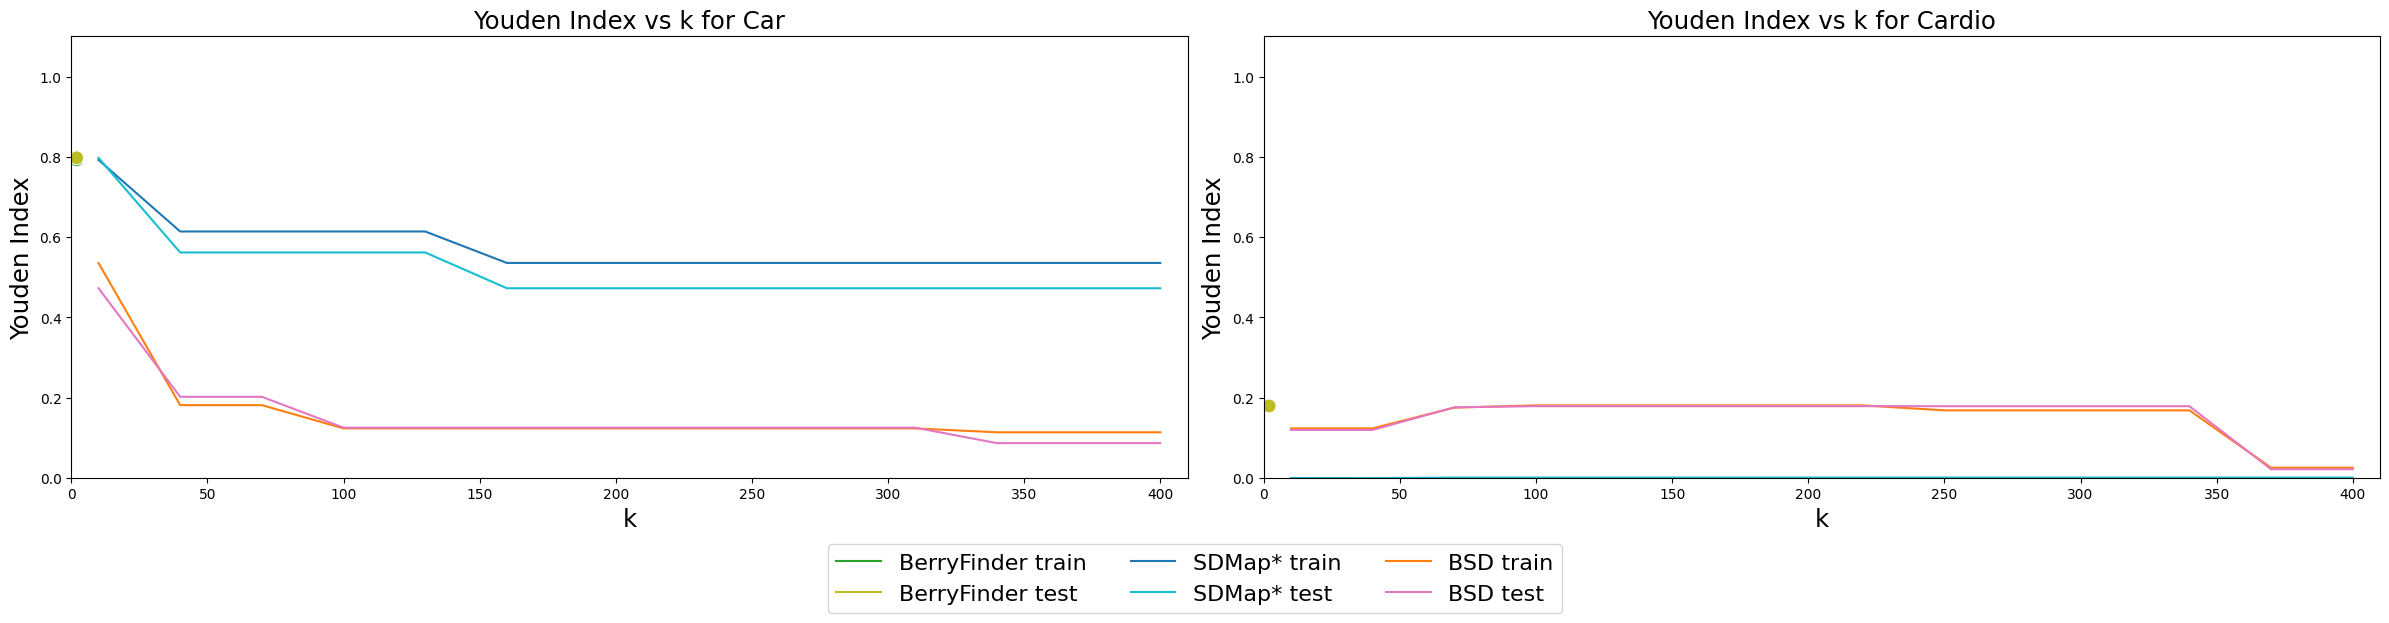

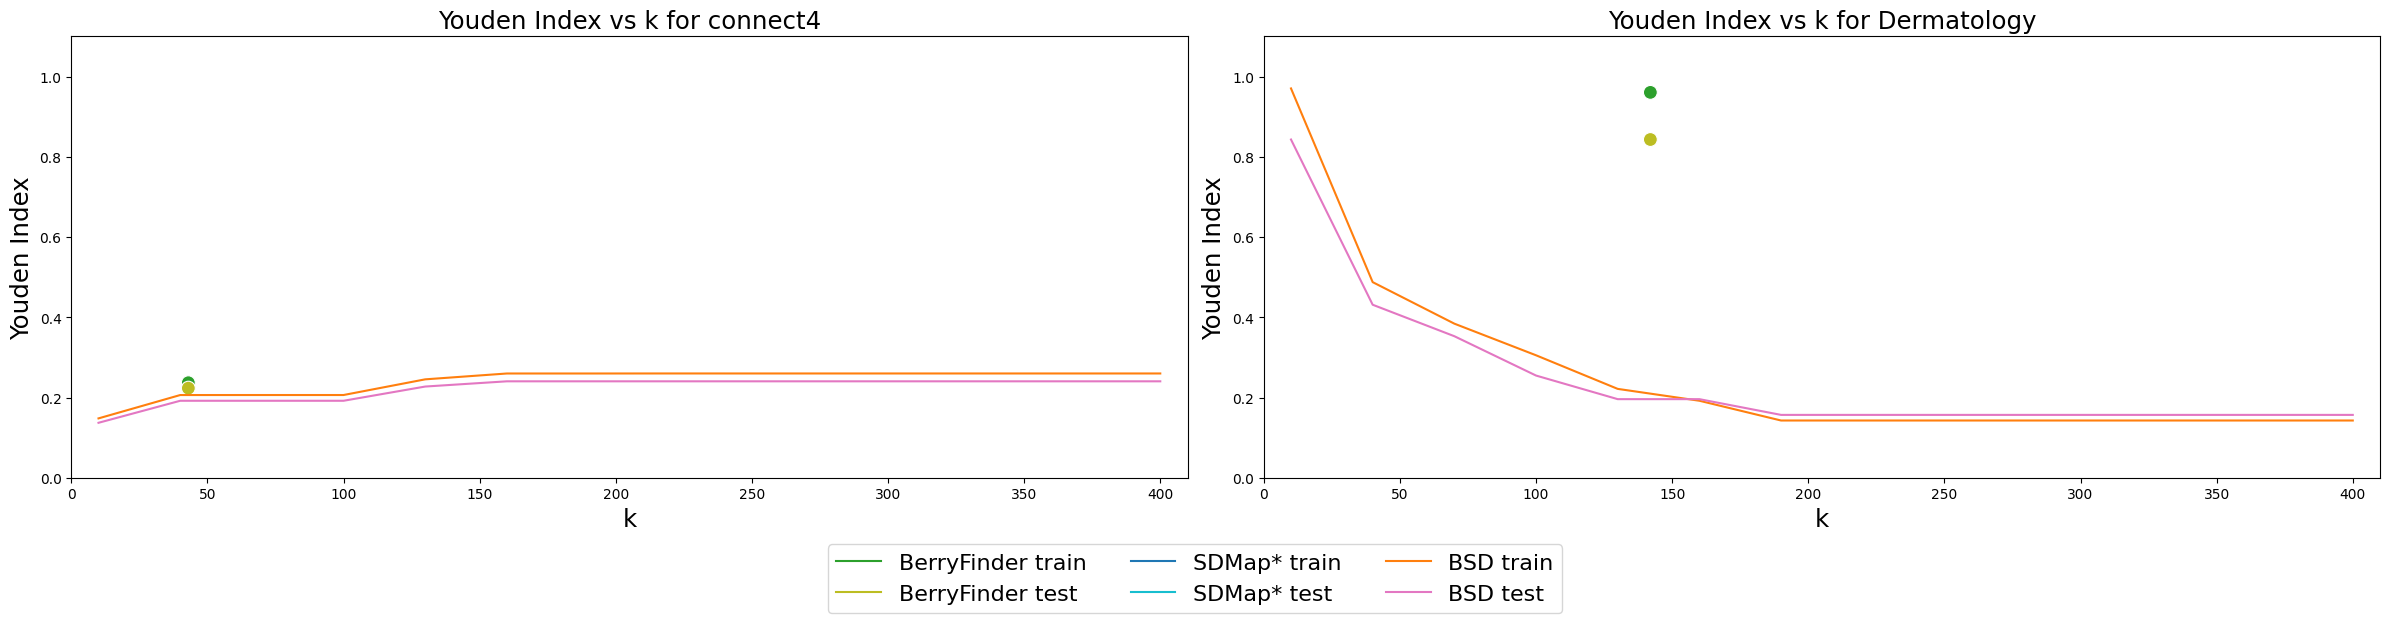

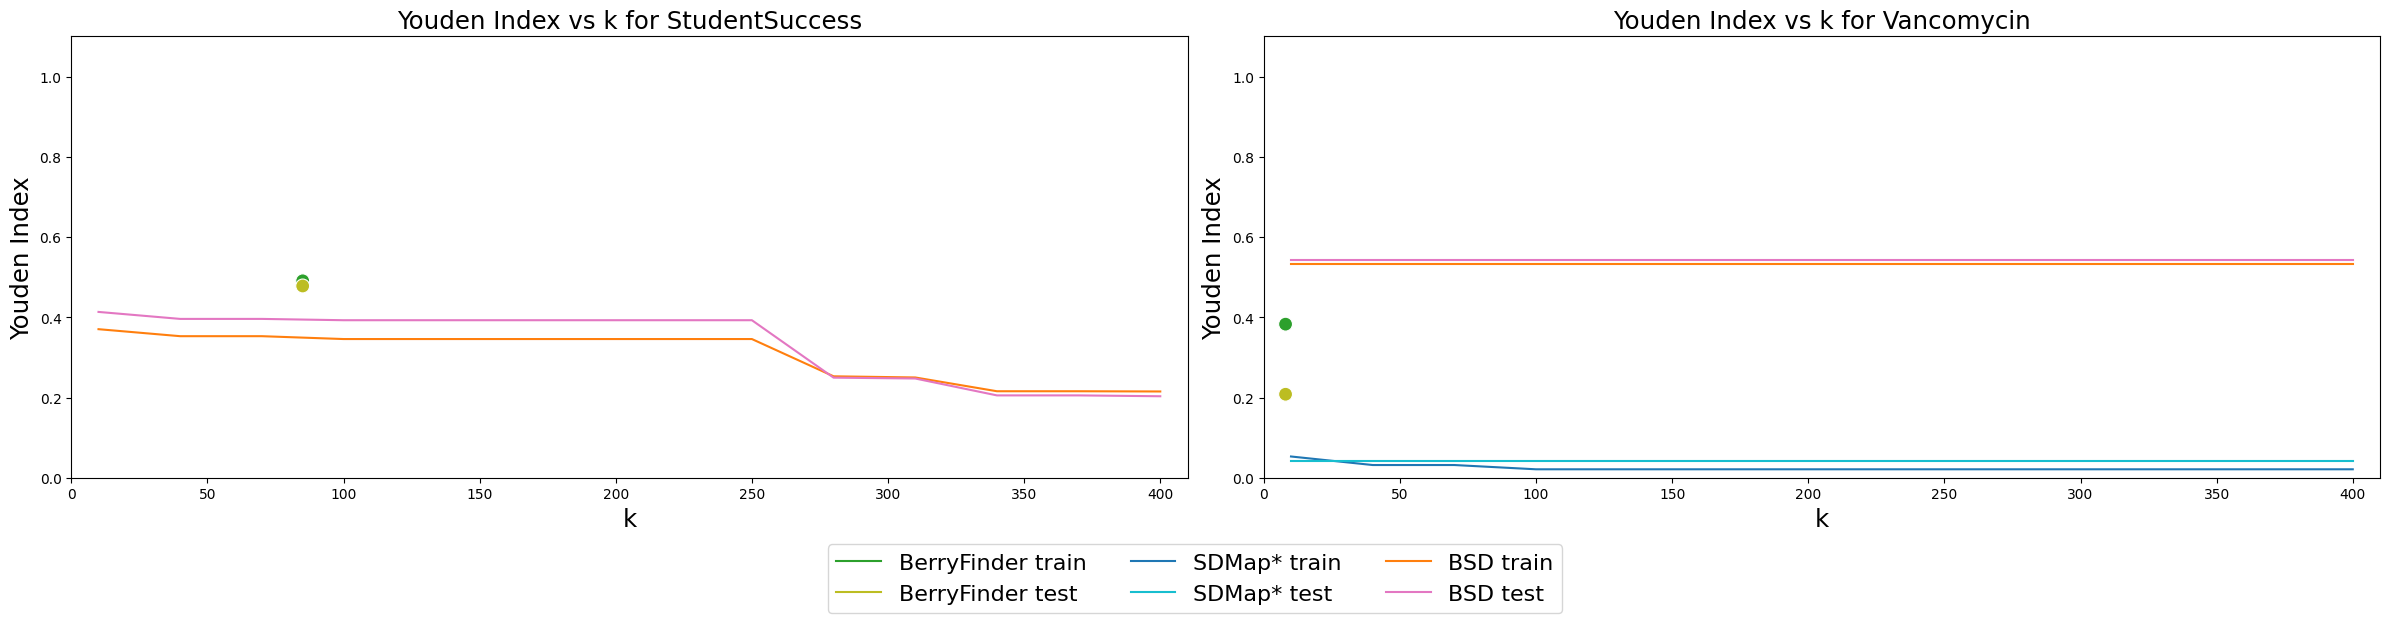

In [9]:
# Pair plots and save them
dataset_pairs = [("Car", "Cardio"), ("connect4", "Dermatology"), ("StudentSuccess", "Vancomycin")]

for d1, d2 in dataset_pairs:
    figure, axes = plt.subplots(1, 2, figsize=(24, 6))
    fontsize = 22
    for i in range(2):
        ax = axes[i]
        d = d1 if i == 0 else d2
        df_d = df[df['database'] == d]
        df_d_melt = df_d.melt(id_vars=['model', 'k'], value_vars=['train', 'test'], var_name='set', value_name='Youden_index')
        df_d_melt["hue"] = df_d_melt["model"] + " " + df_d_melt["set"]
        sns.lineplot(data=df_d_melt, x='k', y='Youden_index', hue='hue', markers=True, dashes=False, palette=color_map, ax=ax, hue_order=label_order)
        sns.scatterplot(data=df_d_melt[df_d_melt["model"] == "BerryFinder"], x='k', y='Youden_index', hue='hue', s=100, legend=False, palette=color_map, ax=ax, hue_order=label_order)
        ax.set_title(f'Youden Index vs k for {d}', fontsize=fontsize*0.8)
        ax.set_xlabel('k', fontsize=fontsize*0.8)
        ax.set_ylabel('Youden Index', fontsize=fontsize*0.8)
        ax.set_ylim(0,1.1 )
        ax.set_xlim(0, 410)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend().remove()
        # ax.legend(title='', fontsize=fontsize*0.8)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    figure.legend(handles, labels, loc='lower center', ncol=3, fontsize=16, bbox_to_anchor=(0.5, -0.1))
    plt.savefig(f'Appendix_B_plots/{d1}_{d2}_pairplot.png', bbox_inches='tight')

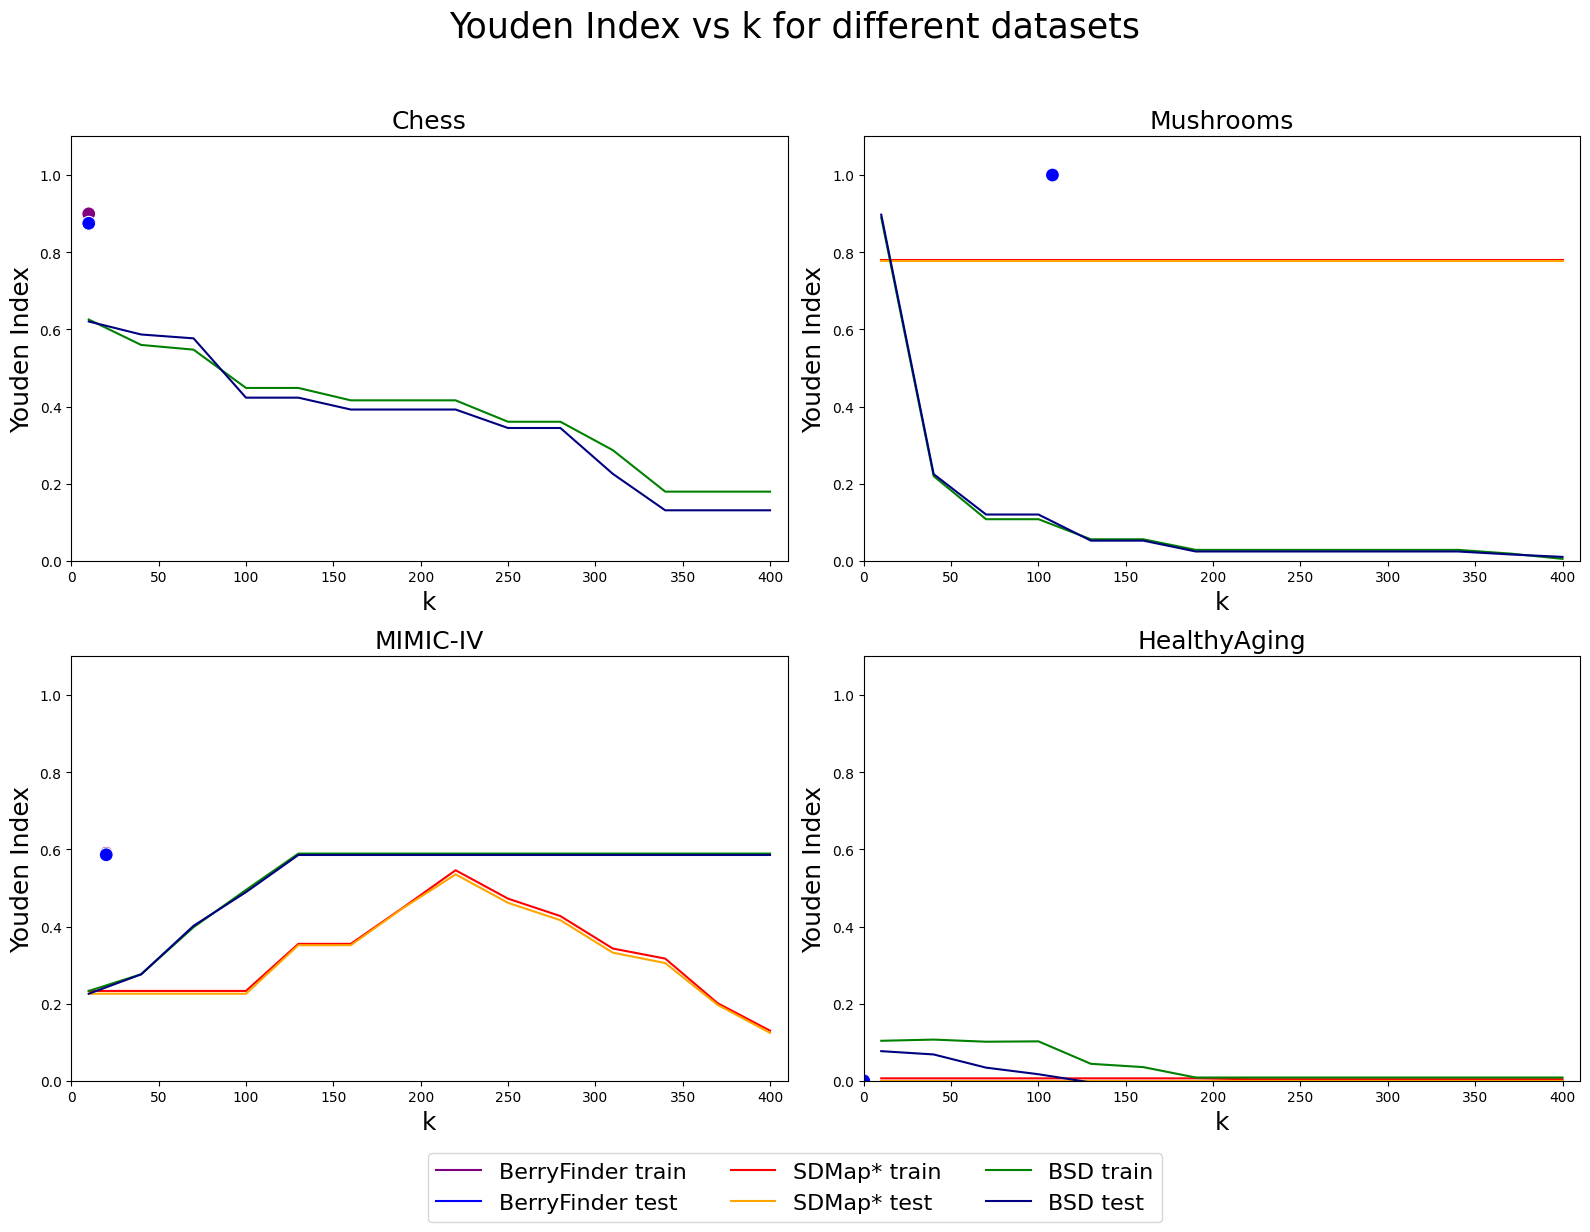

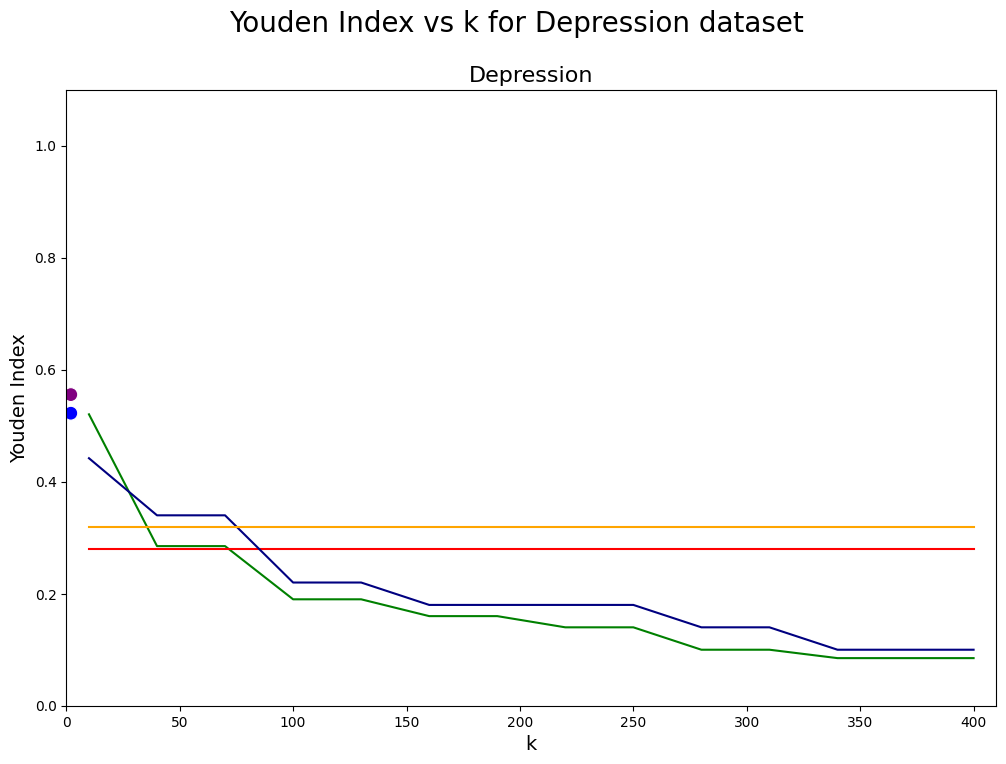

In [ ]:
# Depression, Soybean, Chess, and StudentSuccess

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Youden Index vs k for different datasets', fontsize=25)
datasets = ['Chess', 'Mushrooms', 'MIMIC-IV', 'HealthyAging']
for i, d in enumerate(datasets, 1):
    ax = fig.add_subplot(2, 2, i)
    ax.set_title(d, fontsize=18)
    ax.set_xlabel('k', fontsize=18)
    ax.set_ylabel('Youden Index', fontsize=18)
    df_d = df[df['database'] == d]
    df_d_melt = df_d.melt(id_vars=['model', 'k'], value_vars=['train', 'test'], var_name='set', value_name='Youden_index')
    df_d_melt["hue"] = df_d_melt["model"] + " " + df_d_melt["set"]
    sns.lineplot(data=df_d_melt, x='k', y='Youden_index', hue='hue', markers=True, dashes=False, palette=color_map, ax=ax, hue_order=label_order)
    sns.scatterplot(data=df_d_melt[df_d_melt["model"] == "BerryFinder"], x='k', y='Youden_index', hue='hue', s=100, legend=False, palette=color_map, ax=ax, hue_order=label_order)
    ax.set_ylim(0, 1.1)
    ax.set_xlim(0, 410)
    if i == 3:
        handles, labels = ax.get_legend_handles_labels()
    ax.legend().remove()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Place the legend outside the plot, bottom center
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=16, bbox_to_anchor=(0.5, -0.04))
plt.show()


datasets = ["Depression"]
fig = plt.figure(figsize=(12, 8))
fig.suptitle('Youden Index vs k for Depression dataset', fontsize=20)
for d in datasets:
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(d, fontsize=16)
    ax.set_xlabel('k', fontsize=14)
    ax.set_ylabel('Youden Index', fontsize=14)
    df_d = df[df['database'] == d]
    df_d_melt = df_d.melt(id_vars=['model', 'k'], value_vars=['train', 'test'], var_name='set', value_name='Youden_index')
    df_d_melt["hue"] = df_d_melt["model"] + " " + df_d_melt["set"]
    sns.lineplot(data=df_d_melt, x='k', y='Youden_index', hue='hue', markers=True, dashes=False, palette=color_map, ax=ax)
    sns.scatterplot(data=df_d_melt[df_d_melt["model"] == "BerryFinder"], x='k', y='Youden_index', hue='hue', s=100, legend=False, palette=color_map, ax=ax)
    ax.set_ylim(0, 1.1)
    ax.set_xlim(0, 410)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend().remove()